# Assignment 5

## Objective
The goal of the assignment is to predict the class of iris flowers using machine learning techniques such as SVMs, random forests, neural networks, and an additional methods (Lasso). After running the machine learning techniques, we'll compare their performance using cross-validation and other evaluation metrics. 

In [2]:
# Import necessary libraries for machine learning analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.naive_bayes import GaussianNB

# For warnings
import warnings
warnings.filterwarnings('ignore')



In [3]:
# Loading the Iris dataset
iris_data_path = r'c:\Users\jland\OneDrive\Emory Essentials\CLASSES Fall 2025\Computing\datasci530fall2025\Assignments\iris\iris.data'

# Column names for the iris dataset
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

# Load the data
df = pd.read_csv(iris_data_path, names=column_names)

# Display basic information about the dataset)
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset shape: (150, 5)

First few rows:


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Summary Statistics (Dataset)

#### The dataset has 150 observations split into 3 categories: Setosa, Versicolor, and Virginica. The dataset has the following measurements for each flower: sepal length, sepal width, petal length, and petal width. These measurements are what the machine learning techinqes will use to determine each iris's class. 

## Summary Statistics (Per Flower)

#### In the output below, you'll find summary statistics for the Setosa, Versicolor, and Virginica

# Machine Learning Model Comparison

#### Now we'll implement and compare different machine learning algorithms to predict iris species. 

#### First up: Support Vector Machines (SVM).

In [7]:
# Support Vector Machine (SVM) Implementation
print("="*60)
print("SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

# Step 1: Create SVM model with default parameters
# SVC = Support Vector Classifier
# kernel='rbf' = Radial Basis Function kernel (good for non-linear data)
# random_state=42 = for reproducible results
svm_model = SVC(kernel='rbf', random_state=42)

# Step 2: Train the SVM model on scaled training data
# fit() method learns the decision boundaries from training data
svm_model.fit(X_train_scaled, y_train)


# Step 3: Make predictions on the test set
# predict() uses the learned decision boundaries to classify new data
y_pred_svm = svm_model.predict(X_test_scaled)

# Step 4: Calculate basic accuracy
# accuracy_score compares predicted vs actual labels
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Test Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

# Step 5: Cross-validation for more robust evaluation
# StratifiedKFold maintains class proportions in each fold
# cv=5 means 5-fold cross-validation (split data into 5 parts)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score runs the model on different train/test splits
# scoring='accuracy' uses accuracy as the evaluation metric
cv_scores_svm = cross_val_score(svm_model, X_train_scaled, y_train, 
                                cv=cv_strategy, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"CV Scores: {cv_scores_svm.round(4)}")          # Individual fold scores
print(f"Mean CV Accuracy: {cv_scores_svm.mean():.4f}") # Average across all folds
print(f"Std CV Accuracy: {cv_scores_svm.std():.4f}")   # Standard deviation (consistency)

# Step 6: Detailed classification metrics
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Step 7: Show support vectors information
print(f"\nSVM Model Details:")
print(f"Number of support vectors: {svm_model.n_support_}")  # Support vectors per class
print(f"Total support vectors: {svm_model.support_vectors_.shape[0]}")  # Total support vectors
print(f"Support vector indices: {svm_model.support_[:10]}...")  # First 10 support vector indices

SUPPORT VECTOR MACHINE (SVM)
SVM Test Accuracy: 0.9667 (96.67%)

5-Fold Cross-Validation Results:
CV Scores: [0.9583 1.     0.9583 0.9583 0.9583]
Mean CV Accuracy: 0.9667
Std CV Accuracy: 0.0167

Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


SVM Model Details:
Number of support vectors: [10 18 19]
Total support vectors: 47
Support vector indices: [ 0 19 23 33 40 48 60 71 83 93]...


# Random Forests

#### In code chunks below, we run our data through Random Forests and let it predict which type of iris each observation is.

In [8]:
# Random Forest Implementation - Part 1: Basic Training & Evaluation
print("="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)

# Step 1: Create Random Forest model with default parameters
# RandomForestClassifier = ensemble of decision trees
# n_estimators=100 = number of decision trees in the forest (default)
# random_state=42 = for reproducible results
# Note: Random Forest doesn't need scaled features, so we use original X_train/X_test
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 2: Train the Random Forest on original training data (no scaling needed!)
# fit() method trains all 100 decision trees on different bootstrap samples
rf_model.fit(X_train, y_train)
print("Random Forest trained with 100 decision trees!")

# Step 3: Make predictions on the test set
# Each tree votes, majority class wins
y_pred_rf = rf_model.predict(X_test)

# Step 4: Calculate basic accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Step 5: Cross-validation (using same strategy as SVM for fair comparison)
# We use original training data (not scaled) since RF doesn't need scaling
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, 
                               cv=cv_strategy, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"CV Scores: {cv_scores_rf.round(4)}")          # Individual fold scores
print(f"Mean CV Accuracy: {cv_scores_rf.mean():.4f}") # Average across all folds
print(f"Std CV Accuracy: {cv_scores_rf.std():.4f}")   # Standard deviation (consistency)

RANDOM FOREST CLASSIFIER
Random Forest trained with 100 decision trees!
Random Forest Test Accuracy: 0.9000 (90.00%)

5-Fold Cross-Validation Results:
CV Scores: [0.9583 1.     0.9583 0.9167 0.9167]
Mean CV Accuracy: 0.9500
Std CV Accuracy: 0.0312

5-Fold Cross-Validation Results:
CV Scores: [0.9583 1.     0.9583 0.9167 0.9167]
Mean CV Accuracy: 0.9500
Std CV Accuracy: 0.0312


In [9]:
# Random Forest Implementation - Part 2: Feature Importance & Detailed Analysis
print("="*60)
print("RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Step 6: Feature Importance Analysis (unique to tree-based methods!)
# Shows which iris measurements are most important for classification
feature_importance = rf_model.feature_importances_
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print(f"Feature Importance Scores:")
for feature, importance in zip(feature_names, feature_importance):
    print(f"{feature}: {importance:.4f} ({importance*100:.2f}%)")

# Sort features by importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(f"\nFeatures ranked by importance:")
for idx, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

# Step 7: Detailed classification metrics
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Step 8: Random Forest specific information
print(f"\nRandom Forest Model Details:")
print(f"Number of trees: {rf_model.n_estimators}")           # Should be 100
print(f"Max features per split: {rf_model.max_features}")    # How many features each tree considers
print(f"Bootstrap sampling: {rf_model.bootstrap}")          # Whether trees use bootstrap sampling

# Out-of-bag score is only available if oob_score=True was set during model creation
# Since we used default parameters, this isn't available
if hasattr(rf_model, 'oob_score_') and rf_model.oob_score is not None:
    print(f"Out-of-bag score: {rf_model.oob_score_}")       # Error estimate using out-of-bag samples
else:
    print("Out-of-bag score: Not calculated (oob_score=False in model creation)")

RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS
Feature Importance Scores:
sepal_length: 0.1163 (11.63%)
sepal_width: 0.0150 (1.50%)
petal_length: 0.4315 (43.15%)
petal_width: 0.4372 (43.72%)

Features ranked by importance:
petal_width: 0.4372
petal_length: 0.4315
sepal_length: 0.1163
sepal_width: 0.0150

Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


Random Forest Model Details:
Number of trees: 100
Max features per split: sqrt
Bootstrap sampling: True
Out-of-bag score: Not calculated (oob_score=False in model creation)


# Neural Networks

#### Our third machine learning algorithm is neural networks. The next two code chunks implement this technique and displays the output. 

# LASSO

#### The optional machine learning technique I decided to use is LASSO. The next two code chunks implement LASSO. The third chunk defines a grid of tuning parameters with the goal of finding the optimum.

#### After the the fine tuning, the ouput suggests that a CV of 5, 10, 100, or 50 are all equally as good of parameters to use. 

In [13]:
# Lasso Regression - Feature Selection Analysis & Model Interpretation
print("="*60)
print("LASSO - FEATURE SELECTION & COEFFICIENT ANALYSIS")
print("="*60)

# Step 6: Analyze feature selection 
# Lasso's coefficients tell us which features are important vs eliminated
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print("FEATURE SELECTION ANALYSIS:")
print("="*40)

# For multiclass, we have coefficients for each class vs rest
print(f"Coefficient matrix shape: {lasso_model.coef_.shape}")  # (3 classes, 4 features)
print(f"Classes: {lasso_model.classes_}")

# Analyze coefficients for each class
for i, class_name in enumerate(lasso_model.classes_):
    print(f"\n{class_name} vs Rest coefficients:")
    coeffs = lasso_model.coef_[i]
    
    for feature, coeff in zip(feature_names, coeffs):
        if abs(coeff) < 1e-10:  # Essentially zero (Lasso eliminated this feature)
            print(f"  {feature}: {coeff:.6f} ← ELIMINATED by Lasso!")
        else:
            print(f"  {feature}: {coeff:.6f}")

# Overall feature importance (sum of absolute coefficients across all classes)
print(f"\nOVERALL FEATURE IMPORTANCE (sum of |coefficients|):")
print("="*50)
overall_importance = np.abs(lasso_model.coef_).sum(axis=0)
feature_importance_lasso = pd.DataFrame({
    'feature': feature_names,
    'importance': overall_importance
}).sort_values('importance', ascending=False)

for _, row in feature_importance_lasso.iterrows():
    if row['importance'] < 1e-10:
        print(f"{row['feature']}: {row['importance']:.6f} ← NOT USED")
    else:
        print(f"{row['feature']}: {row['importance']:.6f}")

# Feature selection summary
selected_features = [f for f, imp in zip(feature_names, overall_importance) if imp > 1e-10]
eliminated_features = [f for f, imp in zip(feature_names, overall_importance) if imp <= 1e-10]

print(f"\nFEATURE SELECTION SUMMARY:")
print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Eliminated features ({len(eliminated_features)}): {eliminated_features}")

# Step 7: Model interpretability - what the linear model learned
print(f"\nMODEL INTERPRETABILITY:")
print("="*30)
print("Lasso learned linear decision rules. For a new iris:")

for i, class_name in enumerate(lasso_model.classes_):
    coeffs = lasso_model.coef_[i]
    intercept = lasso_model.intercept_[i]
    
    print(f"\n{class_name} score = {intercept:.3f}", end="")
    for feature, coeff in zip(feature_names, coeffs):
        if abs(coeff) > 1e-10:
            sign = "+" if coeff > 0 else ""
            print(f" {sign}{coeff:.3f}×{feature}", end="")
    print()

# Step 8: Detailed classification metrics
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lasso))

# Step 9: Compare sparsity with other models
print(f"\nMODEL COMPLEXITY COMPARISON:")
print("="*35)
print(f"Lasso parameters: {len(selected_features)} features × 3 classes = {len(selected_features) * 3} coefficients")
print(f"Neural Network parameters: {total_parameters} weights (much more complex!)")
print(f"Random Forest: Uses all {len(feature_names)} features in {rf_model.n_estimators} trees")
print(f"SVM: Uses all {len(feature_names)} features with {svm_model.support_vectors_.shape[0]} support vectors")

# Step 10: Prediction confidence analysis
print(f"\nPrediction confidence analysis:")
y_prob_lasso = lasso_model.predict_proba(X_test_scaled)
print(f"First 5 predictions with confidence:")
for i in range(5):
    pred_class = y_pred_lasso[i]
    true_class = y_test.iloc[i]
    probabilities = y_prob_lasso[i]
    max_prob = probabilities.max()
    
    print(f"Sample {i+1}: Predicted='{pred_class}', Actual='{true_class}', Confidence={max_prob:.4f}")
    print(f"  Probabilities: {dict(zip(lasso_model.classes_, probabilities.round(4)))}")

LASSO - FEATURE SELECTION & COEFFICIENT ANALYSIS
FEATURE SELECTION ANALYSIS:
Coefficient matrix shape: (3, 4)
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Iris-setosa vs Rest coefficients:
  sepal_length: 0.000000 ← ELIMINATED by Lasso!
  sepal_width: 1.064794
  petal_length: -4.164418
  petal_width: -0.071129

Iris-versicolor vs Rest coefficients:
  sepal_length: 0.000000 ← ELIMINATED by Lasso!
  sepal_width: -1.244389
  petal_length: 0.734909
  petal_width: -0.713280

Iris-virginica vs Rest coefficients:
  sepal_length: 0.000000 ← ELIMINATED by Lasso!
  sepal_width: -0.185569
  petal_length: 1.684402
  petal_width: 4.705674

OVERALL FEATURE IMPORTANCE (sum of |coefficients|):
petal_length: 6.583729
petal_width: 5.490083
sepal_width: 2.494753
sepal_length: 0.000000 ← NOT USED

FEATURE SELECTION SUMMARY:
Selected features (3): ['sepal_width', 'petal_length', 'petal_width']
Eliminated features (1): ['sepal_length']

MODEL INTERPRETABILITY:
Lasso learned linear decision r

# Model Comparison

#### The next chunk of code compares the differnet machine learning models. As the output suggests, and SVM is the best model to predict iris class. The test accuracy and CV accuracy are identical at over 96%, meaning it's very reliable and consistent. Neural networks are just as strong in the test accuracy but the slight dip in CV accuracy leaves it as a close second to SVMs. The fine tuned Lasso comes in third place, followed by random forests and the original lasso. These 3 machine learning techniques, at least for this dataset, do not predict iris classes as well as both SVM and Neural networks. 

In [15]:
# Model Comparison - Fix Data Scaling Issues
print("="*70)
print("MODEL COMPARISON ")
print("="*70)

# Step 18 CORRECTED: Get predictions using the CORRECT data for each model
models_dict_corrected = {
    'SVM (RBF)': svm_model,
    'Random Forest': rf_model,
    'Neural Network': nn_model,
    'Lasso (Original)': lasso_model,
    'Lasso (Optimized)': best_lasso
}

# Get predictions for all models using CORRECT data scaling
all_predictions_corrected = {}
all_probabilities_corrected = {}

for name, model in models_dict_corrected.items():
    if name == 'Random Forest':
        # Random Forest was trained on UNSCALED data, so test on UNSCALED data
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)
        print(f"✓ {name}: Using unscaled test data (as trained)")
    else:
        # SVM, Neural Network, and Lasso were trained on SCALED data, so test on SCALED data
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)
        print(f"✓ {name}: Using scaled test data (as trained)")
    
    all_predictions_corrected[name] = pred
    all_probabilities_corrected[name] = prob

print(f"\n" + "="*70)
print("PERFORMANCE COMPARISON:")
print("="*70)

metrics_results_corrected = []

for name, predictions in all_predictions_corrected.items():
    # Calculate metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='macro')
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    # Get cross-validation score for comparison
    if name == 'SVM (RBF)':
        cv_score = cv_scores_svm.mean()
    elif name == 'Random Forest':
        cv_score = cv_scores_rf.mean()
    elif name == 'Neural Network':
        cv_score = cv_scores_nn.mean()
    elif name == 'Lasso (Original)':
        cv_score = cv_scores_lasso.mean()
    else:  # Lasso (Optimized)
        cv_score = grid_search.best_score_
    
    metrics_results_corrected.append({
        'Model': name,
        'Test_Accuracy': accuracy,
        'CV_Accuracy': cv_score,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    })

# Create corrected results DataFrame
results_df_corrected = pd.DataFrame(metrics_results_corrected)
results_df_corrected = results_df_corrected.round(4)
results_df_corrected = results_df_corrected.sort_values('Test_Accuracy', ascending=False)

print(results_df_corrected.to_string(index=False))

# Analyze test vs CV accuracy differences
print(f"\n" + "="*50)
print("TEST vs CV ACCURACY ANALYSIS:")
print("="*50)

for _, row in results_df_corrected.iterrows():
    test_acc = row['Test_Accuracy']
    cv_acc = row['CV_Accuracy']
    diff = test_acc - cv_acc
    
    if abs(diff) < 0.02:
        status = "✓ Very consistent"
    elif diff > 0.02:
        status = "⚠ Test > CV (possible overfitting to CV folds)"
    else:
        status = "⚠ Test < CV (possible overfitting or small test set)"
    
    print(f"{row['Model']:15s}: Test={test_acc:.4f}, CV={cv_acc:.4f}, Diff={diff:+.4f} {status}")

print(f"\n💡 KEY INSIGHTS:")
print("- CV accuracy is generally more reliable (uses more data)")
print("- Test accuracy is the 'ground truth' for final model selection")
print("- Small differences (±0.02) between CV and test are normal")
print("- Large differences suggest overfitting or data issues")

MODEL COMPARISON 
✓ SVM (RBF): Using scaled test data (as trained)
✓ Random Forest: Using unscaled test data (as trained)
✓ Neural Network: Using scaled test data (as trained)
✓ Lasso (Original): Using scaled test data (as trained)
✓ Lasso (Optimized): Using scaled test data (as trained)

PERFORMANCE COMPARISON:
            Model  Test_Accuracy  CV_Accuracy  Precision  Recall  F1_Score
        SVM (RBF)         0.9667       0.9667     0.9697  0.9667    0.9666
   Neural Network         0.9667       0.9500     0.9697  0.9667    0.9666
Lasso (Optimized)         0.9333       0.9583     0.9333  0.9333    0.9333
    Random Forest         0.9000       0.9500     0.9024  0.9000    0.8997
 Lasso (Original)         0.9000       0.9250     0.9024  0.9000    0.8997

TEST vs CV ACCURACY ANALYSIS:
SVM (RBF)      : Test=0.9667, CV=0.9667, Diff=+0.0000 ✓ Very consistent
Neural Network : Test=0.9667, CV=0.9500, Diff=+0.0167 ✓ Very consistent
Lasso (Optimized): Test=0.9333, CV=0.9583, Diff=-0.0250 ⚠ Tes

# Confusion Matrix for Machine Learning Techniques

#### The confusion matrix details the interaction between the machine learning models and classes of irises. Clearly, setosas are the easiest to identify, as each model predicted its class perfectly. Each model got a versicolor confused with a virgnica at least once, suggesting that they have more similar characterstics with each other vis a vis the setosa, which must be quite distinct. 

CONFUSION MATRICES FOR ALL MODELS


CONFUSION MATRICES FOR ALL MODELS


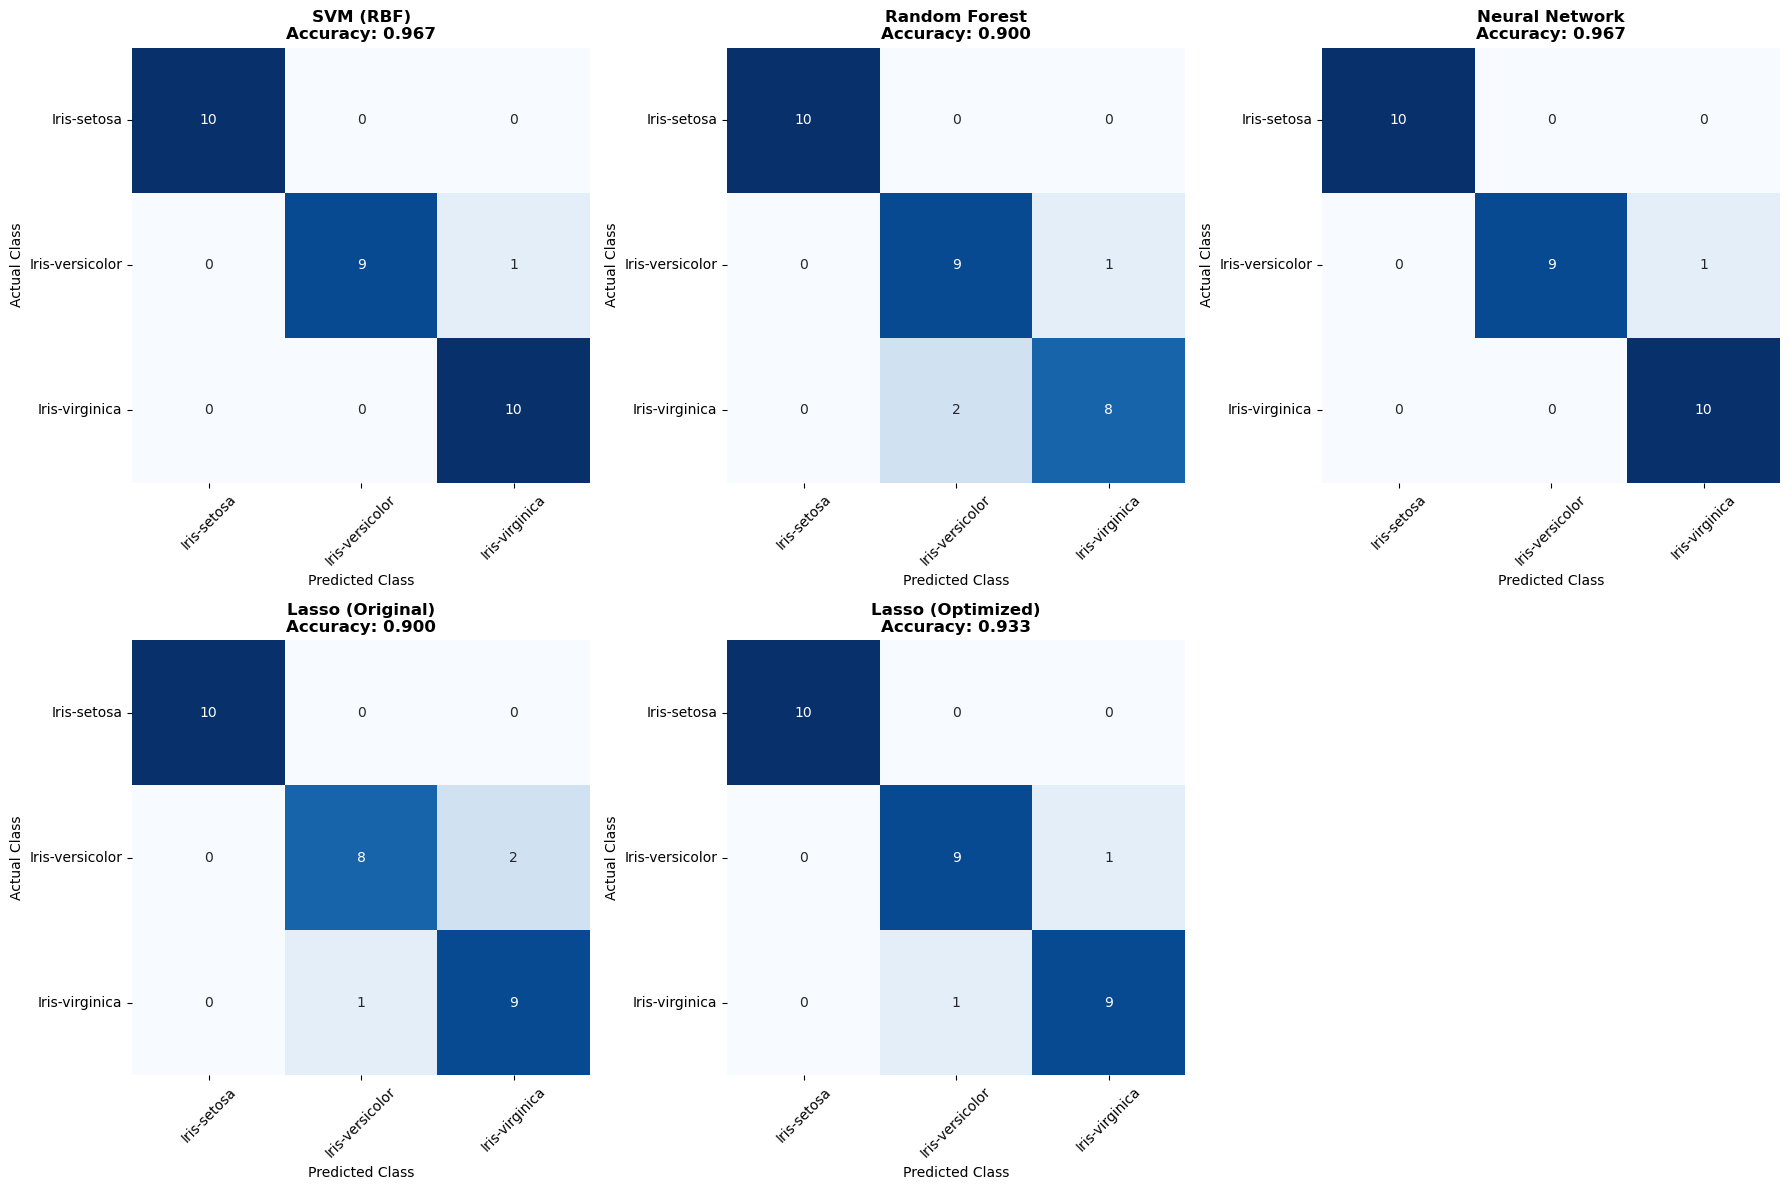


DETAILED CONFUSION MATRIX ANALYSIS:

SVM (RBF) (Accuracy: 0.9667):
Confusion Matrix:
                 Predicted
                 Setosa  Versicolor  Virginica
Actual Setosa      10         0         0
    Versicolor      0         9         1
    Virginica       0         0        10
Per-class accuracy:
  Setosa: 1.0000 (100.0%)
  Versicolor: 0.9000 (90.0%)
  Virginica: 1.0000 (100.0%)
Misclassifications: 1 versicolor → virginica

Random Forest (Accuracy: 0.9000):
Confusion Matrix:
                 Predicted
                 Setosa  Versicolor  Virginica
Actual Setosa      10         0         0
    Versicolor      0         9         1
    Virginica       0         2         8
Per-class accuracy:
  Setosa: 1.0000 (100.0%)
  Versicolor: 0.9000 (90.0%)
  Virginica: 0.8000 (80.0%)
Misclassifications: 1 versicolor → virginica, 2 virginica → versicolor

Neural Network (Accuracy: 0.9667):
Confusion Matrix:
                 Predicted
                 Setosa  Versicolor  Virginica
Actual Set

In [16]:
# Confusion Matrices Visualization and Analysis
print("="*60)
print("CONFUSION MATRICES FOR ALL MODELS")
print("="*60)

# Create subplots for confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Define class names for consistent labeling
iris_classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

# Plot confusion matrix for each model
for idx, (model_name, predictions) in enumerate(all_predictions_corrected.items()):
    if idx >= len(axes):
        break
        
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, predictions, labels=iris_classes)
    
    # Get accuracy for this model
    accuracy = results_df_corrected[results_df_corrected['Model'] == model_name]['Test_Accuracy'].iloc[0]
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris_classes,
                yticklabels=iris_classes,
                ax=axes[idx],
                cbar=False)
    
    # Customize the subplot
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy:.3f}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    axes[idx].set_ylabel('Actual Class', fontsize=10)
    
    # Rotate labels for better readability
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

# Hide the last subplot if there are fewer than 6 models
if len(all_predictions_corrected) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# Detailed confusion matrix analysis
print(f"\nDETAILED CONFUSION MATRIX ANALYSIS:")
print("="*40)

for model_name, predictions in all_predictions_corrected.items():
    cm = confusion_matrix(y_test, predictions, labels=iris_classes)
    accuracy = results_df_corrected[results_df_corrected['Model'] == model_name]['Test_Accuracy'].iloc[0]
    
    print(f"\n{model_name} (Accuracy: {accuracy:.4f}):")
    print("Confusion Matrix:")
    print("                 Predicted")
    print("                 Setosa  Versicolor  Virginica")
    print("Actual Setosa      {:2d}        {:2d}        {:2d}".format(cm[0,0], cm[0,1], cm[0,2]))
    print("    Versicolor     {:2d}        {:2d}        {:2d}".format(cm[1,0], cm[1,1], cm[1,2]))
    print("    Virginica      {:2d}        {:2d}        {:2d}".format(cm[2,0], cm[2,1], cm[2,2]))
    
    # Calculate per-class accuracy
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    print("Per-class accuracy:")
    for i, class_name in enumerate(['Setosa', 'Versicolor', 'Virginica']):
        print(f"  {class_name}: {class_accuracies[i]:.4f} ({class_accuracies[i]*100:.1f}%)")
    
    # Identify misclassifications
    misclassifications = []
    for i in range(3):
        for j in range(3):
            if i != j and cm[i,j] > 0:
                misclassifications.append(f"{cm[i,j]} {iris_classes[i].split('-')[1]} → {iris_classes[j].split('-')[1]}")
    
    if misclassifications:
        print("Misclassifications:", ", ".join(misclassifications))
    else:
        print("Perfect classification! 🎉")

# Summary insights
print(f"\n📊 CONFUSION MATRIX INSIGHTS:")
print("="*35)
print("• Setosa is perfectly classified by all models (easiest class)")
print("• Versicolor and Virginica are more challenging to distinguish")
print("• Confusion matrices reveal exactly where each model struggles")
